In [47]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [29]:
df = pd.read_csv('../data/Telc_customer_churn_cleaned.csv')

# Drop the target and ANY other column that implicitly leaks the target
leakage_cols = ['Churn Value', 'CustomerID', 'Churn Score', 'Satisfaction Score']
X = df.drop(leakage_cols, axis=1, errors='ignore')
y = df['Churn Value']

df

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Churn Reason,Contract_One year,Contract_Two year,Internet Service_Fiber optic,Internet Service_No,Payment Method_Credit card (automatic),Payment Method_Electronic check,Payment Method_Mailed check,avg_monthly_spend,has_multiple_services
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,1,...,Competitor made better offer,False,False,False,False,False,False,True,36.050000,True
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,0,...,Moved,False,False,True,False,False,True,False,50.550000,False
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,0,...,Moved,False,False,True,False,False,True,False,91.166667,False
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,0,...,Moved,False,False,True,False,False,True,False,105.036207,False
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,1,...,Competitor had better devices,False,False,True,False,False,False,False,100.726000,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7027,2569-WGERO,1,United States,California,Landers,92285,"34.341737, -116.539416",34.341737,-116.539416,0,...,NaN,False,True,False,True,False,False,False,19.443836,False
7028,6840-RESVB,1,United States,California,Adelanto,92301,"34.667815, -117.536183",34.667815,-117.536183,1,...,NaN,True,False,False,False,False,False,True,79.620000,True
7029,2234-XADUH,1,United States,California,Amboy,92304,"34.559882, -115.637164",34.559882,-115.637164,0,...,NaN,True,False,True,False,True,False,False,100.861644,False
7030,4801-JZAZL,1,United States,California,Angelus Oaks,92305,"34.1678, -116.86433",34.167800,-116.864330,0,...,NaN,False,False,False,False,False,True,False,28.870833,False


In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

In [34]:
# Select only numerical columns for scaling
X_train_num = X_train.select_dtypes(include=['number'])
X_test_num = X_test.select_dtypes(include=['number'])

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_num)
X_test_sc = scaler.transform(X_test_num)


In [37]:
# Baseline: Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_sc, y_train)
print("LR AUC:", roc_auc_score(y_test, lr.predict_proba(X_test_sc)[:,1]))

LR AUC: 0.8354903168695094


In [41]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_num, y_train)
print("RF AUC:", roc_auc_score(y_test, rf.predict_proba(X_test_num)[:,1]))
print(classification_report(y_test, rf.predict(X_test_num)))

RF AUC: 0.8302630829679403
              precision    recall  f1-score   support

           0       0.82      0.91      0.86      1033
           1       0.64      0.47      0.54       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.70      1407
weighted avg       0.78      0.79      0.78      1407



In [42]:
# 1. Print Random Forest feature importances
importances = pd.Series(rf.feature_importances_, index=X_train_num.columns)
print("--- TOP 5 LEAKING FEATURES ---")
print(importances.sort_values(ascending=False).head(5))

print("\n--- CORRELATION WITH TARGET ---")
# 2. Check direct linear correlation with Churn Value
correlations = X_train_num.corrwith(y_train).abs()
print(correlations.sort_values(ascending=False).head(5))

--- TOP 5 LEAKING FEATURES ---
Tenure Months        0.146068
Monthly Charges      0.141207
Total Charges        0.134435
avg_monthly_spend    0.116731
CLTV                 0.093177
dtype: float64

--- CORRELATION WITH TARGET ---
Tenure Months        0.351710
Dependents           0.254806
Total Charges        0.197988
Monthly Charges      0.193455
Paperless Billing    0.188513
dtype: float64


c:\Users\Elot\Desktop\Telco Churn Analysis\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\Elot\Desktop\Telco Churn Analysis\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


In [45]:
top10 = importances.nlargest(10)
print(top10)

Tenure Months        0.146068
Monthly Charges      0.141207
Total Charges        0.134435
avg_monthly_spend    0.116731
CLTV                 0.093177
Longitude            0.085710
Zip Code             0.084357
Latitude             0.083304
Dependents           0.040640
Paperless Billing    0.021830
dtype: float64


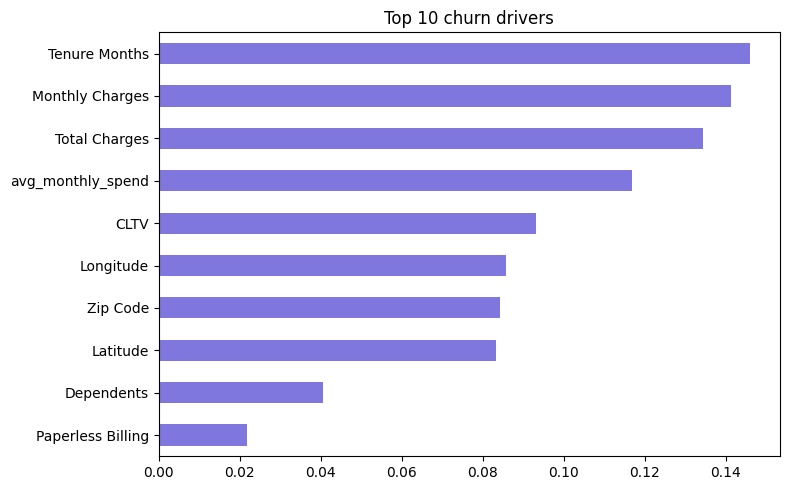

In [48]:
top10.sort_values().plot(kind='barh', figsize=(8,5),
    color='#7F77DD', title='Top 10 churn drivers')
plt.tight_layout()